In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import jax 
from jax import numpy as jnp
from flows.types import *
import optax
from flows.utils import *
from flows.models.linear import Linear
from flows.utils import *
import matplotlib.pyplot as plt
from functools import partial
from flows.Bases import Hermite 
from flows.bases import *
import flax.linen as nn
import sys 
import math
import pickle 
from flows.models.iresnet import InvertibleResNet
from flows.models.MLP import clip_kernel_svd_multiple
from scipy import constants
from sklearn.linear_model import LinearRegression

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Computer Modern Roman'
fontsize_label = 18
fontsize_title = fontsize_label + 1
fontsize_legend = fontsize_label - 4
# size of the ticks 
plt.rcParams['xtick.labelsize'] = fontsize_label - 5
plt.rcParams['ytick.labelsize'] = fontsize_label - 5

print(f"available devices: {jax.devices()}")

available devices: [CpuDevice(id=0)]


In [22]:

def fit_power_law(N, losses2):
    N = np.asarray(N)
    losses2 = np.asarray(losses2)

    mask = (losses2 > 0) & (N > 0)
    N = N[mask]
    losses2 = losses2[mask]

    logN = np.log(N)
    logL = np.log(losses2)

    # linear fit: logL = -m logN + b
    A = np.vstack([logN, np.ones_like(logN)]).T
    slope, intercept = np.linalg.lstsq(A, logL, rcond=None)[0]

    m = -slope
    return m


def fit_stretched_exponential(N, losses1):
    N = np.asarray(N)
    losses1 = np.asarray(losses1)

    mask = (losses1 > 0) & (losses1 < 1) & (N > 0)
    N = N[mask]
    losses1 = losses1[mask]

    logN = np.log(N)
    Y = np.log(-np.log(losses1))

    # linear fit: Y = log(c) + delta logN
    A = np.vstack([logN, np.ones_like(logN)]).T
    delta, log_c = np.linalg.lstsq(A, Y, rcond=None)[0]

    c = np.exp(log_c)
    return c, delta

(5, 23) (23,) (5, 23) (5,)
[1838.97289536 1838.97288808 1838.97288786 1838.97288778 1838.97288777]
[ 1838.97288682  5394.31903179  8786.19900521 12014.61280708
 15079.5604374  17981.04189618 20719.05718339 23293.60629906
 25704.68924318 27952.30601575 30036.45661677 31957.14104623
 33714.35930415 35308.11139051 36738.39730533 38005.21704859
 39108.57062031 40048.45802047 40824.87924908 41437.83430614
 41887.32319165 42173.34590561 42295.90244802]
N: [22 24 26 28 30]
0 & 1.506 & \textbf{21.575} & 6.434 \\
1 & 13.099 & \textbf{20.398} & 12.932 \\
2 & 16.612 & 18.845 & \textbf{19.632} \\
3 & 14.676 & 16.970 & \textbf{25.519} \\
4 & 12.325 & 17.015 & \textbf{29.531} \\
5 & 9.632 & 17.776 & \textbf{31.434} \\
6 & 6.920 & 17.050 & \textbf{31.166} \\
7 & 4.794 & 15.533 & \textbf{29.879} \\
8 & 3.441 & 14.087 & \textbf{28.437} \\
9 & 2.640 & 12.631 & \textbf{27.279} \\
10 & 2.150 & 11.504 & \textbf{26.564} \\
11 & 1.831 & 10.936 & \textbf{25.923} \\
12 & 1.612 & 10.760 & \textbf{25.038} \\
13 

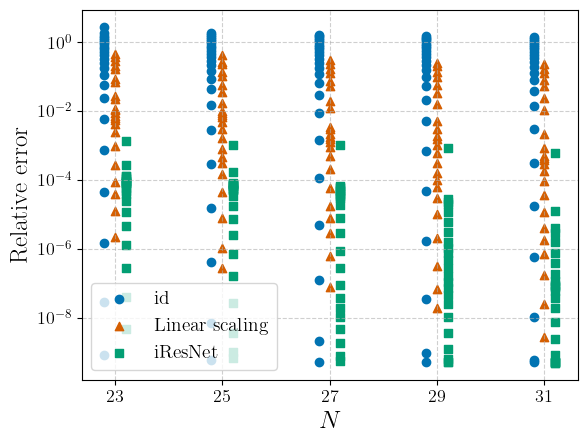

In [28]:
mO, mH = [15.994914619257,1.00782503223]
m1 = mH
m2 = mO
a_m,D_m,x0_m = 2.1440, 42301, 0.0
def get_exact(no_states,D,a):
    D_si = D * 100 * constants.h * constants.c#[J]
    a_si = a * 10**(10)
    c_cms = constants.c * 100 #[cm/s]
    amu = constants.u
    mu = m1 * m2 / (m1 + m2) * amu #kg
    freq = a_si / (2*jnp.pi * c_cms) * jnp.sqrt(2 * D_si / mu)
    anh_freq = freq**2 / (4 * D)
    v = jnp.arange(no_states)
    return freq * (0.5 + v) - anh_freq * (0.5 + v)**2

e_exact = get_exact(23, D_m, a_m)
# load the Morse potential data
data = np.load("simulations_data/Morse_Hermite.npz")
N = data["N_values"]
e_values = data["e_values"]

data_scaled = np.load("simulations_data/Morse_scaled_Hermite.npz")
e_values_scaled = data_scaled["e_values"]
print(e_values_scaled.shape, e_exact.shape, e_values.shape, N.shape)
data_NF = np.load("simulations_data/Morse_NF_Hermite.npz")
e_values_NF = data_NF["e_values"]

print(e_values_NF[:,0])
print(e_exact)
k = 0
print(f"N: {N}")

improvement_res = 0
improvement_scaled = 0

for k, (e_vals, e_vals_scaled, e_vals_NF) in enumerate(
    zip(e_values.T, e_values_scaled.T, e_values_NF.T)
):
    # Compute relative errors
    err_id = np.abs(e_vals - e_exact[k]) / e_exact[k]
    err_scaled = np.abs(e_vals_scaled - e_exact[k]) / e_exact[k]
    err_nf = np.abs(e_vals_NF - e_exact[k]) / e_exact[k]

    # Fit power laws
    exp_id = fit_power_law(N + 1, err_id)
    exp_scaled = fit_power_law(N + 1, err_scaled)
    exp_nf = fit_power_law(N + 1, err_nf)

    improvement_res += exp_nf/exp_id
    improvement_scaled += exp_scaled/exp_id
    
    exps = [exp_id, exp_scaled, exp_nf]
    max_val = max(exps)

    # Format with bold for maximum (handle ties with tolerance)
    tol = 1e-10
    formatted = [
        f"\\textbf{{{v:.3f}}}" if abs(v - max_val) < tol else f"{v:.3f}"
        for v in exps
    ]

    print(f"{k} & {formatted[0]} & {formatted[1]} & {formatted[2]} \\\\")


print(f"improvement avg: {(improvement_res/23):.3f}")
print(f"improvement scaled: {(improvement_scaled/23):3f}")

fig, ax = plt.subplots()
first = True

for e_val, e_val_scaled, e_val_NF, n in zip(e_values, e_values_scaled, e_values_NF, N):
    n += 1
    ax.scatter(np.repeat(n, e_val.shape[0])-0.2, np.abs(e_val-e_exact)/e_exact, label="id" if first else None, color='#0173B2')
    ax.scatter(np.repeat(n, e_val_scaled.shape[0]), np.abs(e_val_scaled-e_exact)/e_exact, label="Linear scaling" if first else None, color='#D55E00', marker='^')
    ax.scatter(np.repeat(n, e_val_NF.shape[0])+0.2, np.abs(e_val_NF-e_exact)/e_exact, label="iResNet" if first else None, marker='s', color='#029E73')    
    first = False
plt.xlabel(r"$N$", fontsize=fontsize_label)
plt.ylabel("Relative error", fontsize=fontsize_label)
plt.xticks(N+1)
plt.legend(fontsize=fontsize_legend)
plt.yscale("log")
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.savefig("Morse.pdf", dpi=300, bbox_inches='tight')
plt.show()

Plot the (transformed) target functions

In [35]:
# accuracy for m=0, 23 and N=33
acc_res_0 = np.abs(e_values_NF[0, 0] - e_exact[0]) / e_exact[0]
acc_res_23 = np.abs(e_values_NF[0, 22] - e_exact[22]) / e_exact[22]
acc_Hermite_0 = np.abs(e_values[0, 0] - e_exact[0]) / e_exact[0]
acc_Hermite_23 = np.abs(e_values[0, 22] - e_exact[22]) / e_exact[22]
acc_linear_scaled_0 = np.abs(e_values_scaled[0, 0] - e_exact[0]) / e_exact[0]
acc_linear_scaled_23 = np.abs(e_values_scaled[0, 22] - e_exact[22]) / e_exact[22]

print(f"Improvement of accuracy for m=0, 23 and N=33:")
print(f"iResNet: m=0: {acc_res_0:.3e}, m=23: {acc_res_23:.3e}")
print(f"Hermite: m=0: {acc_Hermite_0:.3e}, m=23: {acc_Hermite_23:.3e}")
print(f"Linear scaling: m=0: {acc_linear_scaled_0:.3e}, m=23: {acc_linear_scaled_23:.3e}")

# improvement in accuracy 
improvement_acc_res_0 =  acc_Hermite_0/acc_res_0
improvement_acc_res_23 = acc_Hermite_23/acc_res_23
improvement_acc_scaled_0 = acc_Hermite_0/acc_linear_scaled_0
improvement_acc_scaled_23 = acc_Hermite_23/acc_linear_scaled_23
print(f"Improvement in accuracy iResNetfor m=0: {improvement_acc_res_0:.3f}, m=23: {improvement_acc_res_23:.3f}")
print(f"Improvement in accuracy for linear scaling m=0: {improvement_acc_scaled_0:.3f}, m=23: {improvement_acc_scaled_23:.3f}")


Improvement of accuracy for m=0, 23 and N=33:
iResNet: m=0: 4.643e-09, m=23: 1.388e-03
Hermite: m=0: 8.485e-10, m=23: 2.823e+00
Linear scaling: m=0: 2.248e-06, m=23: 4.429e-01
Improvement in accuracy iResNetfor m=0: 0.183, m=23: 2033.918
Improvement in accuracy for linear scaling m=0: 0.000, m=23: 6.375


(5, 23) (23,) (5, 23) (5,)
[1838.97289536 1838.97288808 1838.97288786 1838.97288778 1838.97288777]
[ 1838.97288682  5394.31903179  8786.19900521 12014.61280708
 15079.5604374  17981.04189618 20719.05718339 23293.60629906
 25704.68924318 27952.30601575 30036.45661677 31957.14104623
 33714.35930415 35308.11139051 36738.39730533 38005.21704859
 39108.57062031 40048.45802047 40824.87924908 41437.83430614
 41887.32319165 42173.34590561 42295.90244802]
N: [22 24 26 28 30]
0 & 1.681e+01, 0.071 & 1.985e-01, \textbf{1.338} & 7.353e+00, 0.317 \\
1 & 2.104e+00, 0.678 & 1.326e-01, \textbf{1.427} & 2.218e+00, 0.672 \\
2 & 4.912e-01, 1.055 & 9.992e-02, \textbf{1.477} & 5.661e-01, 1.073 \\
3 & 2.197e-01, 1.218 & 9.087e-02, \textbf{1.472} & 1.463e-01, 1.466 \\
4 & 9.596e-02, 1.379 & 4.732e-02, 1.638 & 4.790e-02, \textbf{1.787} \\
5 & 4.885e-02, 1.486 & 1.768e-02, 1.905 & 2.181e-02, \textbf{2.008} \\
6 & 3.678e-02, 1.474 & 1.060e-02, 2.030 & 1.470e-02, \textbf{2.110} \\
7 & 3.762e-02, 1.376 & 9.674e-03

/var/folders/tm/8mqg54_17kg5g6dwhzldtpkr0000gp/T/ipykernel_96702/4249265397.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  improvement_res += exp_nf / exp_id
/var/folders/tm/8mqg54_17kg5g6dwhzldtpkr0000gp/T/ipykernel_96702/4249265397.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  improvement_scaled += exp_scaled / exp_id


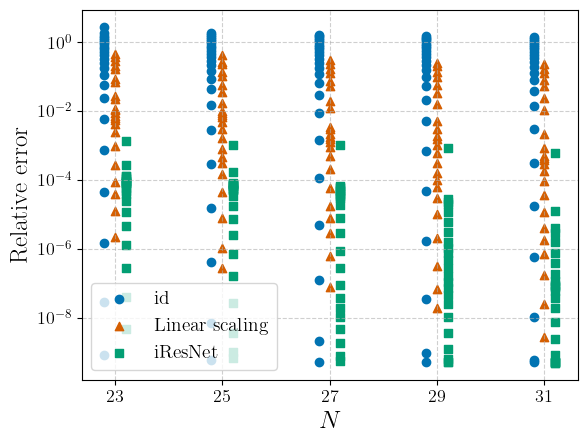

In [37]:
mO, mH = [15.994914619257,1.00782503223]
m1 = mH
m2 = mO
a_m,D_m,x0_m = 2.1440, 42301, 0.0
def get_exact(no_states,D,a):
    D_si = D * 100 * constants.h * constants.c#[J]
    a_si = a * 10**(10)
    c_cms = constants.c * 100 #[cm/s]
    amu = constants.u
    mu = m1 * m2 / (m1 + m2) * amu #kg
    freq = a_si / (2*jnp.pi * c_cms) * jnp.sqrt(2 * D_si / mu)
    anh_freq = freq**2 / (4 * D)
    v = jnp.arange(no_states)
    return freq * (0.5 + v) - anh_freq * (0.5 + v)**2

e_exact = get_exact(23, D_m, a_m)
# load the Morse potential data
data = np.load("simulations_data/Morse_Hermite.npz")
N = data["N_values"]
e_values = data["e_values"]

data_scaled = np.load("simulations_data/Morse_scaled_Hermite.npz")
e_values_scaled = data_scaled["e_values"]
print(e_values_scaled.shape, e_exact.shape, e_values.shape, N.shape)
data_NF = np.load("simulations_data/Morse_NF_Hermite.npz")
e_values_NF = data_NF["e_values"]

print(e_values_NF[:,0])
print(e_exact)
k = 0
print(f"N: {N}")

improvement_res = 0
improvement_scaled = 0

for k, (e_vals, e_vals_scaled, e_vals_NF) in enumerate(
    zip(e_values.T, e_values_scaled.T, e_values_NF.T)
):
    # Compute relative errors
    err_id = np.abs(e_vals - e_exact[k]) / e_exact[k]
    err_scaled = np.abs(e_vals_scaled - e_exact[k]) / e_exact[k]
    err_nf = np.abs(e_vals_NF - e_exact[k]) / e_exact[k]

    # Fit power laws
    con_id, exp_id = fit_stretched_exponential(N + 1, err_id)
    con_scaled, exp_scaled = fit_stretched_exponential(N + 1, err_scaled)
    con_nf, exp_nf = fit_stretched_exponential(N + 1, err_nf)

    improvement_res += exp_nf / exp_id
    improvement_scaled += exp_scaled / exp_id

    cons = [con_id, con_scaled, con_nf]
    exps = [exp_id, exp_scaled, exp_nf]

    max_val = max(exps)

    tol = 1e-10

    # Format exponent (bold only for max)
    formatted_exps = [
        f"\\textbf{{{v:.3f}}}" if abs(v - max_val) < tol else f"{v:.3f}"
        for v in exps
    ]

    # Print both con and exp
    print(
        f"{k} & "
        f"{cons[0]:.3e}, {formatted_exps[0]} & "
        f"{cons[1]:.3e}, {formatted_exps[1]} & "
        f"{cons[2]:.3e}, {formatted_exps[2]} \\\\"
    )


print(f"improvement avg: {(improvement_res/23):.3f}")
print(f"improvement scaled: {(improvement_scaled/23):3f}")

fig, ax = plt.subplots()
first = True

for e_val, e_val_scaled, e_val_NF, n in zip(e_values, e_values_scaled, e_values_NF, N):
    n += 1
    ax.scatter(np.repeat(n, e_val.shape[0])-0.2, np.abs(e_val-e_exact)/e_exact, label="id" if first else None, color='#0173B2')
    ax.scatter(np.repeat(n, e_val_scaled.shape[0]), np.abs(e_val_scaled-e_exact)/e_exact, label="Linear scaling" if first else None, color='#D55E00', marker='^')
    ax.scatter(np.repeat(n, e_val_NF.shape[0])+0.2, np.abs(e_val_NF-e_exact)/e_exact, label="iResNet" if first else None, marker='s', color='#029E73')    
    first = False
plt.xlabel(r"$N$", fontsize=fontsize_label)
plt.ylabel("Relative error", fontsize=fontsize_label)
plt.xticks(N+1)
plt.legend(fontsize=fontsize_legend)
plt.yscale("log")
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.savefig("Morse.pdf", dpi=300, bbox_inches='tight')
plt.show()